# Piglet Experiment

We are first tasked with reproducing the results from the simplified version of Piglet from within the report. The modified variant of Piglet involves both players taking turns, racing to a score of two. On each turn, the player flips a coin, if the player rolls a head they add one to their turn score, if tails their turn score is reduced to zero and their turn is ended. The player may choose whether to roll or hold if their turn continues, where rolling brings the player closer to victory, but comes with the risk of losing their turn total. We are thus interested in finding the probability of winning from each non-winning state.

We are interested in solving this problem via the value iteration algorithm. We define a the probability of winning from state your score i, opponent score j and current turn score k as $S_{i,j,k}$. There are thus six possible non-winning states we wish to find the probability of winning from. These are $P_{0,0,0}$, $P_{0,0,1}$, $P_{0,1,0}$, $P_{0,1,1}$, $P_{1,0,0}$ and $P_{1,1,0}$.

In [4]:
import matplotlib.pyplot as plt

def piglet_value_iteration(iterations: int = 25):
    """
    Runs value iteration for Piglet with goal = 2

    A state is (i, j, k):
    i = current player's score
    j = opponent's score
    k = current turn total

    Returns the value history for plotting and the final values
    """
    # The six non-winning states for Piglet when the goal is 2
    states = [
        (0, 0, 0),
        (0, 0, 1),
        (0, 1, 0),
        (0, 1, 1),
        (1, 0, 0),
        (1, 1, 0),
    ]

    # Start every win probability estimate at 0.
    value_func = {state: 0 for state in states}
    history = {
        state: [value_func[state]]
        for state in states
    }

    def V(i: int, j: int, k: int) -> float:
        """
        Gets the current value of a state. If the player can already win by holding, return 1
        """
        if i + k >= 2:
            return 1
        return value_func[(i, j, k)]

    # Repeatedly update the value estimates
    for _ in range(iterations):
        for i, j, k in states:
            flip_value = 0.5 * (
                (1.0 - V(j, i, 0)) + V(i, j, k + 1)
            )
            hold_value = 1.0 - V(j, i + k, 0)
            # Selects whether to flip or hold
            value_func[(i, j, k)] = max(flip_value, hold_value)
        # Save values
        for state in states:
            history[state].append(value_func[state])

    return history, value_func


We have now constructed a function that implements the value iteration algorithm, and records the value of the estimate at each iteration. The function below runs our algorithm for twenty five iterations, to replicate the results in the report. It then 

In [6]:
def plot_piglet_figure():
    history, final_values = piglet_value_iteration(iterations=25)

    labels = {
        (0, 0, 0): "P0,0,0",
        (0, 0, 1): "P0,0,1",
        (0, 1, 0): "P0,1,0",
        (0, 1, 1): "P0,1,1",
        (1, 0, 0): "P1,0,0",
        (1, 1, 0): "P1,1,0",
    }

    plot_order = [
        (1, 0, 0),
        (0, 0, 1),
        (1, 1, 0),
        (0, 1, 1),
        (0, 0, 0),
        (0, 1, 0),
    ]

    plt.figure(figsize=(8, 6))

    for state in plot_order:
        y_values = history[state]
        x_values = range(len(y_values))
        plt.plot(
            x_values,
            y_values,
            color="black",
            linewidth=1
        )
        plt.text(
            len(y_values) - 1 + 0.25,
            y_values[-1],
            labels[state],
            va="center",
            fontsize=9
        )

    plt.xlim(0, 25)
    plt.ylim(0, 1)
    plt.xlabel("Iteration")
    plt.ylabel("Win Probability")
    plt.xticks(range(0, 26, 5))
    plt.yticks([x / 10 for x in range(0, 11)])
    plt.subplots_adjust(right=0.82)
    plt.show()
    print("Final values:")
    for state in plot_order:
        print(f"{labels[state]} = {final_values[state]:.6f}")

By running this function, we obtain a graph showing the estiamted value of each probability at each iteration. From this graph we can see that the probability estimates seem to converge after around fifteen iterations. In addition, we can find the exact final values after twenty five iterations as an output from our function.

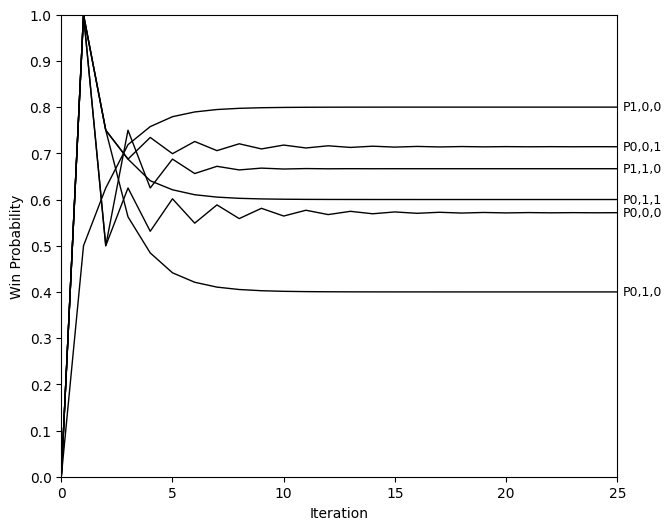

Final values:
P1,0,0 = 0.800000
P0,0,1 = 0.714238
P1,1,0 = 0.666667
P0,1,1 = 0.600000
P0,0,0 = 0.571524
P0,1,0 = 0.400000


In [7]:
plot_piglet_figure()

### Final Results

| State (i,j,k)  | Probability of Winning |
|:--:|:--:|
| (0,0,0) | $\frac{4}{7}$ |
| (0,0,1)| $\frac{5}{7}$ |
| (0,1,0) | $\frac{2}{5}$ |
| (0,1,1) | $\frac{3}{5}$ |
| (1,0,0) | $\frac{4}{5}$ |
| (1,1,0) | $\frac{2}{3}$ |